# Final Pipeline — Quantitative Trading and Price Impact

End-to-end pipeline structured around the `price_impact` module (`src/price_impact/`). The notebook is a thin orchestration layer; the heavy lifting lives in:

| Module | Responsibility |
|---|---|
| `data` | bin loading, ADV / σ, volume curves |
| `impact_states` | normalised $\bar I$ in **both** daily-reset and multi-day variants |
| `fitting` | parametric OLS, rolling baseline, non-parametric extension, half-life grid search |
| `alpha` | synthetic alpha (unbiased, target ρ — from `project.ipynb`) |
| `strategy` | OW, AFS, placeholder for time-dependent λ extended OW |
| `backtest` | Waelbroeck simulator accepting **generic** trade paths |
| `results` | per-day P&L, TCA decomposition, plotting |
| `runner` | `BacktestConfig` + `run_and_save` → `saved/<name>/` |

Each numbered section is one phase of the pipeline; the *Results* section runs multiple configurations in a small loop and writes everything to disk.


## 0. Setup


In [2]:
# from google.colab import drive

# drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# %cd "drive/My Drive/GoogleColab/price_impact_optimal_execution"
# %pip install -e . # Install the project in editable mode

/content/drive/My Drive/GoogleColab/price_impact_optimal_execution
Obtaining file:///content/drive/My%20Drive/GoogleColab/price_impact_optimal_execution
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for price-impact-optimal-execution (pyproject.toml) ... done
  Created wheel for price-impact-optimal-execution: filename=price_impact_optimal_execution-0.1.0-py3-none-any.whl size=1375 sha256=74c91206b1c0cb3d304096e607d56b8eb7c5b53c26ea4962de91629cb91fccd8
  Stored in directory: /tmp/pip-ephem-wheel-cache-0an3uctc/wheels/ac/c1/d3/4743e1feec0f1f21babe365d49859e63d671d0fa59d8b131ad
Successfully built price-impact-optimal-execution
  Attempting uninstall: price-impact-optimal-execution
    Found existing installation: price-impact-optimal-execution 0.1.0
    Uninstalling price-impact-optimal-execution-0.1.0:
     

In [59]:
import sys
from pathlib import Path

# Important: ensure auto-reloading is on so that changes to src/price_impact/
# are reflected automatically without having to restart the kernel.
%load_ext autoreload
%autoreload 2

# Folder layout: final_project/ holds the notebook + src/; the shared
# data/ directory lives at the project root, one level up.
ROOT = Path.cwd()
PROJECT_ROOT = ROOT
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

import price_impact as pi

print("price_impact modules:", [m for m in dir(pi) if not m.startswith("_")][:8], "...")

price_impact modules: ['BacktestConfig', 'BacktestResult', 'DaySimulation', 'ImpactModel', 'PanelData', 'RunOutput', 'afs_optimal_strategy', 'alpha'] ...


## 1. Data Preparation

Load monthly bin CSVs, restrict to the **top-20** stocks by total absolute order-flow volume, then compute trailing 20-day daily statistics ($\sigma_{i,d}$, $\mathrm{ADV}_{i,d}$).


In [2]:
DATA_DIR = PROJECT_ROOT / "data"
YEAR = 2019

panel = pi.build_panel(DATA_DIR, year=YEAR, top_n=20, lookback_days=20)
data = panel.bins
daily_stats = panel.daily_stats
print(
    f"panel: {panel.n_stocks} stocks, {data.shape[0]:,} bin rows, "
    f"{data['date'].nunique()} trading days"
)
daily_stats.head()

panel: 20 stocks, 11,028,752 bin rows, 250 trading days


sigma           ADV
stock date                              
AAL   2019-01-02  0.000493  6.914220e+05
      2019-01-03  0.000653  1.434520e+06
      2019-01-04  0.000615  1.413489e+06
      2019-01-07  0.000614  1.336470e+06
      2019-01-08  0.000603  1.261210e+06

**In-sample / out-of-sample split.** We use rolling monthly windows for the impact-model fitting (Section 3) and reserve the last few months for the backtest in Section 7.


In [44]:
data["month"] = pd.to_datetime(data["date"]).dt.month
print("Bin rows by month:")
print(data.groupby("month").size())


Bin rows by month:
month
1      924314
2      872426
3      961830
4      949533
5     1011602
6      912392
7      977871
8      972308
9      848418
10     982763
11     830026
12     785269
dtype: int64


## 2. Intraday Impact States

Compute the normalised impact state $\bar I_t$ from the OU recursion

$$ \bar I_{t+1} = (1-\beta)\,\bar I_t + \tilde q_t, \qquad \beta = \ln 2 / H_{\text{bins}}. $$

The module returns **both** variants on the same panel so downstream code can pick the one it needs:

- `I_bar_daily` — reset $\bar I \leftarrow 0$ at the start of each (stock, date);
- `I_bar_multi` — carry $\bar I$ across days within a stock, with an overnight decay applied between sessions.

We compute the panel once per (model, $H$) pair — Section 3 reuses this for the fitting and Section 7 reuses it for the backtest's reference impact.


In [119]:
H_FIT = 60.0  # half-life in minutes, will be revisited by the grid search
MODEL_TYPES = ("linear", "sqrt")

impact_panels = {
    mt: pi.compute_impact_states(
        data, daily_stats, half_life_minutes=H_FIT, model_type=mt
    )
    for mt in MODEL_TYPES
}

imp = impact_panels["linear"]
print("Columns:", imp.columns.tolist())
imp.head()


Columns: ['stock', 'date', 'time', 'q_tilde', 'I_bar_daily', 'I_bar_multi']


,stock,date,time,q_tilde,I_bar_daily,I_bar_multi
0,AAL,2019-01-02,09:30:00,-9.025088e-07,-9.025088e-07,-9.025088e-07
1,AAL,2019-01-02,09:30:10,-1.425764e-07,-1.043347e-06,-1.043347e-06
2,AAL,2019-01-02,09:30:20,1.568341e-06,5.270020e-07,5.270020e-07
3,AAL,2019-01-02,09:30:30,-2.972718e-07,2.287155e-07,2.287155e-07
4,AAL,2019-01-02,09:30:40,-1.568341e-06,-1.340066e-06,-1.340066e-06


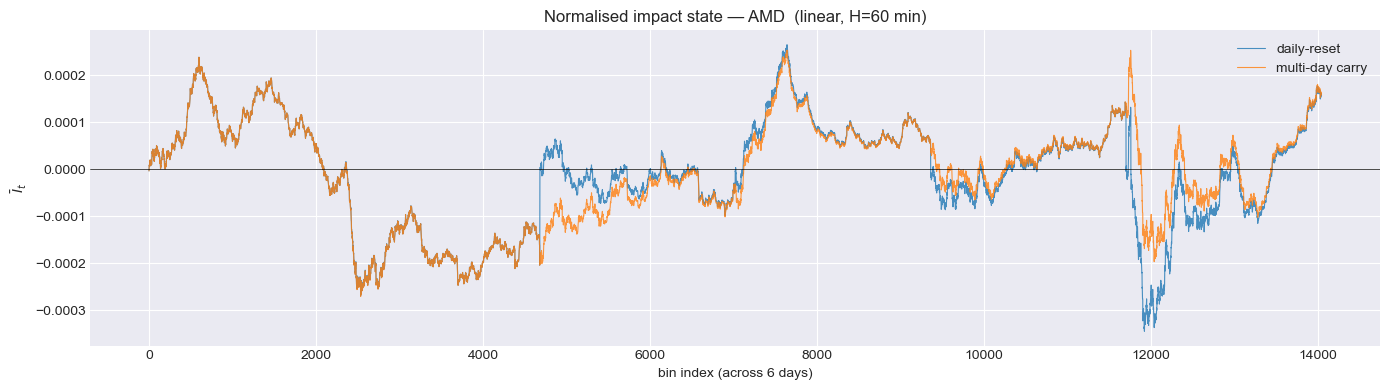

In [129]:
# Quick visual: daily-reset vs multi-day Ī for one (stock, range of dates).
stock_demo = panel.stocks[0]
sample = (
    imp[imp["stock"] == stock_demo].sort_values(["date", "time"]).head(2340 * 6)
)  # ~6 days
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample["I_bar_daily"].values, lw=0.8, label="daily-reset", alpha=0.8)
ax.plot(sample["I_bar_multi"].values, lw=0.8, label="multi-day carry", alpha=0.8)
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"Normalised impact state — {stock_demo}  (linear, H={H_FIT:.0f} min)")
ax.set_xlabel("bin index (across 6 days)")
ax.set_ylabel(r"$\bar I_t$")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Impact Model Fitting — Extended Analysis

Per Anran's Section 2.2: rolling per-stock OLS of $y_t = \alpha + \lambda x_t$ where

$$ y_t = (P_t - P_{t-\tau})/P_{t-\tau}, \qquad x_t = \bar I_t - \bar I_{t-\tau}. $$

The same machinery works on **either** carry mode — set `carry='daily'` or `carry='multi'` and the fitter consumes the right $\bar I$ column.


### 3.1 Half-life grid search


In [ ]:
# Coarse grid; expand if needed. Daily-reset Ī is the standard for fitting.
H_GRID = [5, 10, 20, 30, 45, 60, 90, 120, 180]  # minutes
TAU_BINS = 6  # τ = 1 min explanation horizon (6 bins × 10 s/bin)

grid_df = pi.half_life_grid_search(
    data,
    daily_stats,
    H_grid_minutes=H_GRID,
    tau_bins=TAU_BINS,
    carry="daily",
    model_types=MODEL_TYPES,
    progress=True,
)
best_per_model = (
    grid_df.groupby(["model", "H"])["oos_r2"]
    .mean()
    .reset_index()
    .sort_values(["model", "oos_r2"], ascending=[True, False])
)
print(best_per_model.groupby("model").head(3).to_string(index=False))

H_star = int(np.mean(best_per_model.groupby("model")["H"].first()))
print(f"Adopted universal H* = {H_star} min")

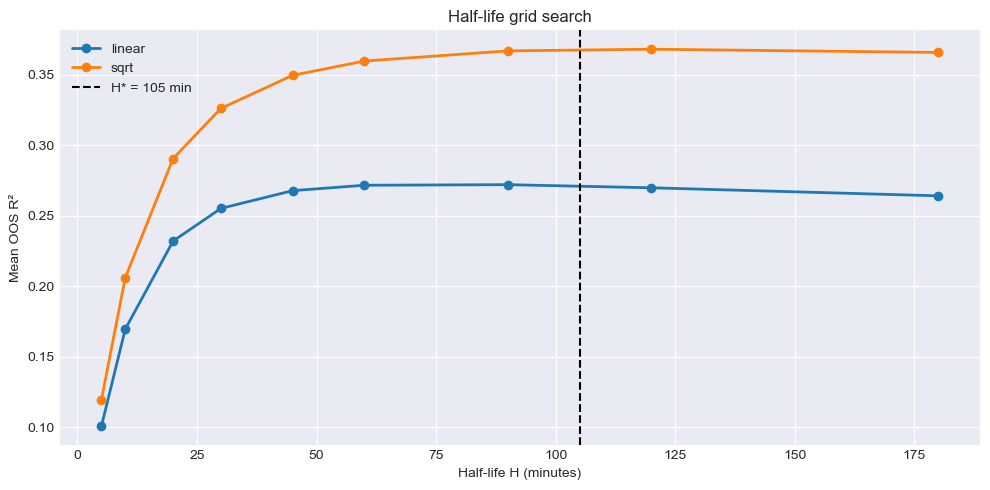

In [101]:
fig, ax = plt.subplots(figsize=(10, 5))
for mt in MODEL_TYPES:
    sub = grid_df[grid_df["model"] == mt].groupby("H")["oos_r2"].mean()
    ax.plot(sub.index, sub.values, "o-", lw=2, label=mt)
ax.axvline(H_star, ls="--", color="black", label=f"H* = {H_star} min")
ax.set_xlabel("Half-life H (minutes)")
ax.set_ylabel("Mean OOS R²")
ax.set_title("Half-life grid search")
ax.legend()
plt.tight_layout()
plt.show()


### 3.2 Parametric rolling baseline — both carry modes


In [29]:
# Recompute impact panels at H* and fit on **both** carry modes so we can
# compare daily-reset vs multi-day Ī.
impact_panels_star = {
    mt: pi.compute_impact_states(data, daily_stats, H_star, model_type=mt)
    for mt in MODEL_TYPES
}

baseline_results = {}
for mt in MODEL_TYPES:
    for carry in ("daily", "multi"):
        feats = pi.build_regression_features(
            impact_panels_star[mt], data, tau_bins=TAU_BINS, carry=carry
        )
        stats = pi.daily_sufficient_stats(feats)
        baseline_results[(mt, carry)] = pi.rolling_baseline(
            stats, n_windows=10, offset=2
        )

summary_rows = []
for (mt, carry), df in baseline_results.items():
    mean_lam = df["lambda"].mean()
    sd_lam = df["lambda"].std()
    summary_rows.append(
        {
            "model": mt,
            "carry": carry,
            "mean_lambda": mean_lam,
            "sd_lambda": sd_lam,
            "t_stat_lambda": mean_lam / sd_lam if sd_lam > 0 else float("nan"),
            "mean_oos_r2": df["oos_r2"].mean(),
            "mean_is_r2": df["is_r2"].mean(),
            "n_rows": len(df),
        }
    )
pd.DataFrame(summary_rows).round(5)


,model,carry,mean_lambda,sd_lambda,t_stat_lambda,mean_oos_r2,mean_is_r2,n_rows
0,linear,daily,119.05417,56.36361,2.11225,0.27092,0.35162,196
1,linear,multi,118.21309,56.09341,2.10743,0.26725,0.34726,196
2,sqrt,daily,9.53233,3.47812,2.74065,0.36776,0.39516,196
3,sqrt,multi,9.47502,3.46146,2.73729,0.36364,0.39068,196


### 3.3 Non-parametric binned extension


In [30]:
# Per-stock binned g(x) shrunk toward a universal curve; γ tuned on the
# month immediately after the training month, OOS scored on m + 2.
feats_lin = pi.build_regression_features(
    impact_panels_star["linear"], data, tau_bins=TAU_BINS, carry="daily"
)
feats_sq = pi.build_regression_features(
    impact_panels_star["sqrt"], data, tau_bins=TAU_BINS, carry="daily"
)

np_lin, fits_lin = pi.rolling_nonparametric(feats_lin, n_bins=15, n_windows=10)
np_sq, fits_sq = pi.rolling_nonparametric(feats_sq, n_bins=15, n_windows=10)

comparison = (
    pd.concat(
        [
            np_lin.assign(model="linear"),
            np_sq.assign(model="sqrt"),
        ]
    )
    .groupby("model")[["oos_r2_raw", "oos_r2_univ", "oos_r2_reg"]]
    .mean()
)
print("OOS R² (mean over windows):")
print(comparison.round(5))


OOS R² (mean over windows):
        oos_r2_raw  oos_r2_univ  oos_r2_reg
model                                      
linear     0.35654      0.34177     0.36790
sqrt       0.38651      0.35720     0.38998


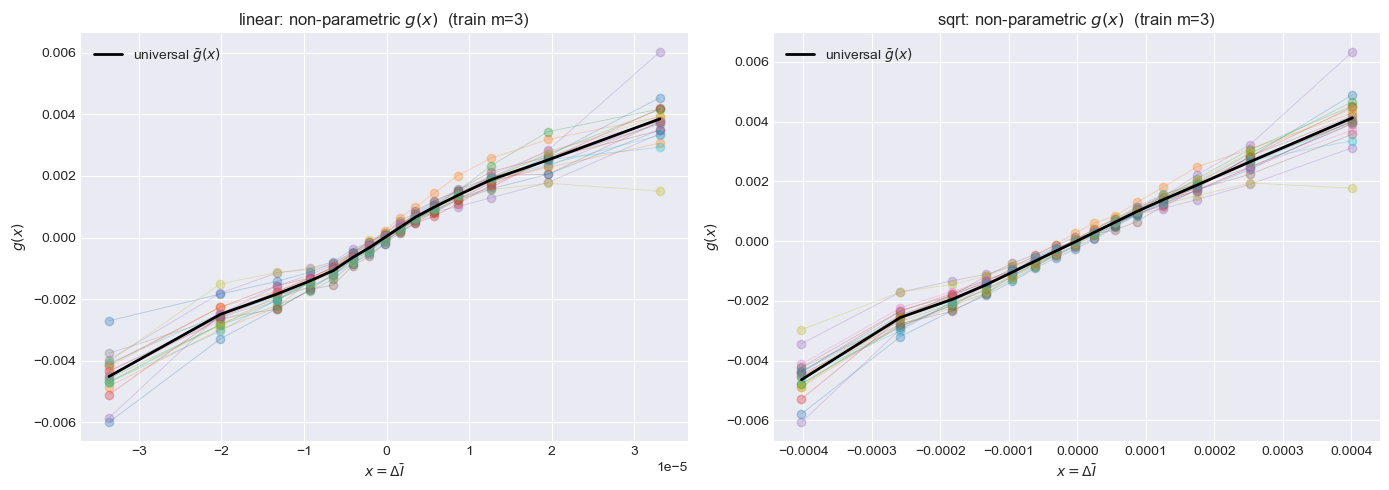

In [10]:
# Estimated impact curves for one window (train month = 3).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mt, fits in zip(axes, MODEL_TYPES, [fits_lin, fits_sq]):
    if 3 not in fits:
        ax.set_title(f"{mt}: no fit for month 3")
        continue
    f = fits[3]
    edges = f.bin_edges
    centers = 0.5 * (edges[:-1] + edges[1:])
    centers[0] = edges[1] - (edges[2] - edges[1])
    centers[-1] = edges[-2] + (edges[-2] - edges[-3])
    for stock, g in f.reg_best.groupby("stock"):
        ax.plot(centers[g["bin"]], g["g_reg"], "o-", lw=0.6, alpha=0.3)
    ax.plot(
        centers,
        f.g_bar.reindex(range(len(centers))).values,
        "k-",
        lw=2,
        label="universal $\\bar g(x)$",
    )
    ax.set_xlabel(r"$x = \Delta \bar I$")
    ax.set_ylabel(r"$g(x)$")
    ax.set_title(f"{mt}: non-parametric $g(x)$  (train m=3)")
    ax.legend()
plt.tight_layout()
plt.show()


### 3.4 Per-stock λ for the backtest


In [ ]:
# Use the mean λ over rolling windows for each (model, carry) combination.
# These dicts feed `BacktestConfig` in Section 7.
lam_lookup_daily = {
    mt: pi.per_stock_lambda(baseline_results[(mt, "daily")]).to_dict()
    for mt in MODEL_TYPES
}
lam_lookup_multi = {
    mt: pi.per_stock_lambda(baseline_results[(mt, "multi")]).to_dict()
    for mt in MODEL_TYPES
}

print("Per-stock λ (linear, daily-reset) stats:")
print(
    pi.per_stock_lambda_stats(baseline_results[("linear", "daily")])
    .sort_values("mean")
    .round(5)
    .to_string()
)


Per-stock λ (linear, daily-reset):
ADSK     49.537050
ADBE     58.741824
AES      67.073035
ADI      90.771498
AMZN     90.797066
APC      98.446974
ADP     109.181624
AOS     110.897495
AFL     113.634220
ADM     117.167533
AEP     119.050400
APA     120.647649
AIG     122.541369
AMAT    125.181048
ABT     132.779029
AAL     141.770923
AMD     145.092116
AMGN    156.267024
ABBV    164.149892
AAPL    239.112758


## 4. Synthetic Alpha

$\alpha_t = r^h_t + y \, dW_t / P_t$ with $y$ chosen so that $\mathrm{Corr}(\alpha, r^h) = \rho$ **and** $E[r^h | \alpha] = \alpha$ (the unbiased construction from `project.ipynb`).


In [12]:
RHO = 0.05
H_ALPHA_BINS = 1  # next-bin forward return

alphas = pi.create_synthetic_alpha(
    data, rho=RHO, h_bins=H_ALPHA_BINS, seed=42, verbose=False
)
emp = alphas.groupby("stock").apply(lambda g: g["alpha"].corr(g["fwd_ret"]))
print(f"Empirical mean Corr(α, r) = {emp.mean():.4f}  (target ρ = {RHO})")
alphas.head()


Empirical mean Corr(α, r) = 0.0503  (target ρ = 0.05)


/var/folders/16/7zq0ws2119n__w35n6n_cy640000gn/T/ipykernel_29373/2693105743.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  emp = alphas.groupby('stock').apply(lambda g: g['alpha'].corr(g['fwd_ret']))


,stock,date,time,alpha,fwd_ret
0,AAL,2019-01-02,09:30:00,0.002177,-0.000159
1,AAL,2019-01-02,09:30:10,-0.008132,-0.000159
2,AAL,2019-01-02,09:30:20,0.005755,0.000000
3,AAL,2019-01-02,09:30:30,0.006261,-0.000952
4,AAL,2019-01-02,09:30:40,-0.015452,-0.000476


## 5. Optimal Trading Strategy

Closed-form OW target position:  $X^*_t = \alpha_t \, \mathrm{ADV}/(2\lambda\sigma)$, adjusted at speed $\kappa = \beta = \ln 2 / H$, ramped down in the final 30 minutes. AFS uses the same target rule (per `project.ipynb`); the sqrt nonlinearity enters via the simulator's impact-state recursion.

For the **extended OW** model with time-dependent $\lambda(t)$, the closed-form solution is more involved — the placeholder lives in
 `price_impact.strategy.ext_ow_optimal_strategy_timedep_lambda` and raises `NotImplementedError` until that derivation is wired in.


AMD 2019-10-07:  OW Σ|q| = 58622, AFS Σ|q| = 58622


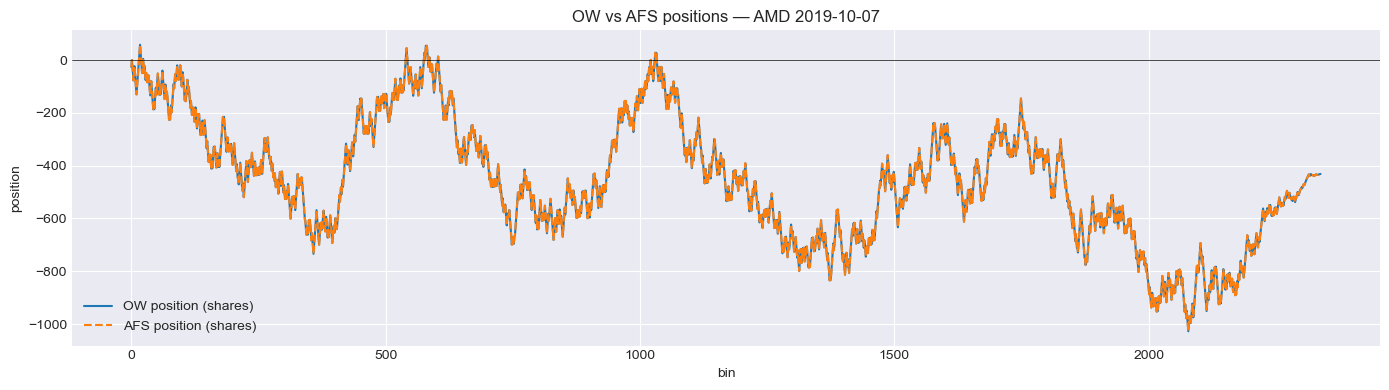

In [13]:
# Sanity check on a synthetic-alpha day.
demo_stock = panel.stocks[0]
demo_date = alphas["date"].iloc[len(alphas) // 2]
mask = (alphas["stock"] == demo_stock) & (alphas["date"] == demo_date)
alpha_demo = alphas.loc[mask, "alpha"].values
stats_demo = daily_stats.loc[(demo_stock, demo_date)]
lam_demo = lam_lookup_daily["linear"][demo_stock]

q_ow = pi.ow_optimal_strategy(
    alpha_demo,
    stats_demo["sigma"],
    stats_demo["ADV"],
    lam=lam_demo,
    half_life_minutes=H_star,
)
q_afs = pi.afs_optimal_strategy(
    alpha_demo,
    stats_demo["sigma"],
    stats_demo["ADV"],
    lam=lam_demo,
    half_life_minutes=H_star,
)
print(
    f"{demo_stock} {demo_date.date()}:  "
    f"OW Σ|q| = {np.sum(np.abs(q_ow)):.0f}, AFS Σ|q| = {np.sum(np.abs(q_afs)):.0f}"
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(np.cumsum(q_ow), label="OW position (shares)")
ax.plot(np.cumsum(q_afs), label="AFS position (shares)", ls="--")
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"OW vs AFS positions — {demo_stock} {demo_date.date()}")
ax.set_xlabel("bin")
ax.set_ylabel("position")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Backtest Engine

Waelbroeck construction:

$$ P_{\text{sim}}(t) = P_0 \bigl(1 + \text{cumret}(t) + g_{\text{sim}}(t) - g_{\text{ref}}(t)\bigr), \quad g(t) = \lambda \bar I(t)\ \text{or}\ \lambda(t)\bar I(t). $$

`run_backtest` accepts **any** signed trade path through a `trade_provider` callable; pass `make_optimal_provider(...)` for OW/AFS, or `make_fixed_provider(...)` for TWAP / VWAP demos. Carry mode is `daily` or `multi`.

Two ways to use it:

1. **Direct.** Call `pi.run_backtest(...)` and post-process yourself.
2. **Wrapped.** Build a `BacktestConfig`, call `pi.run_and_save(...)` — runs, computes metrics + TCA, saves everything under `saved/<name>/`.

Section 7 uses the wrapped form for a small comparison sweep.


## 7. Results — Modular Backtest Sweep

We compare four configurations along two axes — model (OW vs AFS) × carry mode (daily-reset vs multi-day). Each run produces:

- per-day P&L (mid + sim), turnover, max impact dislocation;
- TCA decomposition (net P&L, gross P&L, impact cost, predicted α reward,
 realised α reward);
- cumulative-P&L, drawdown, and impact-dislocation plots.

All artifacts land in `saved/<name>/`.


ow_daily      Sharpe(sim)=+nan  net P&L=$             0  impact cost=$             0


ow_multi      Sharpe(sim)=+nan  net P&L=$             0  impact cost=$             0


afs_daily     Sharpe(sim)=+nan  net P&L=$             0  impact cost=$             0


afs_multi     Sharpe(sim)=+nan  net P&L=$             0  impact cost=$             0


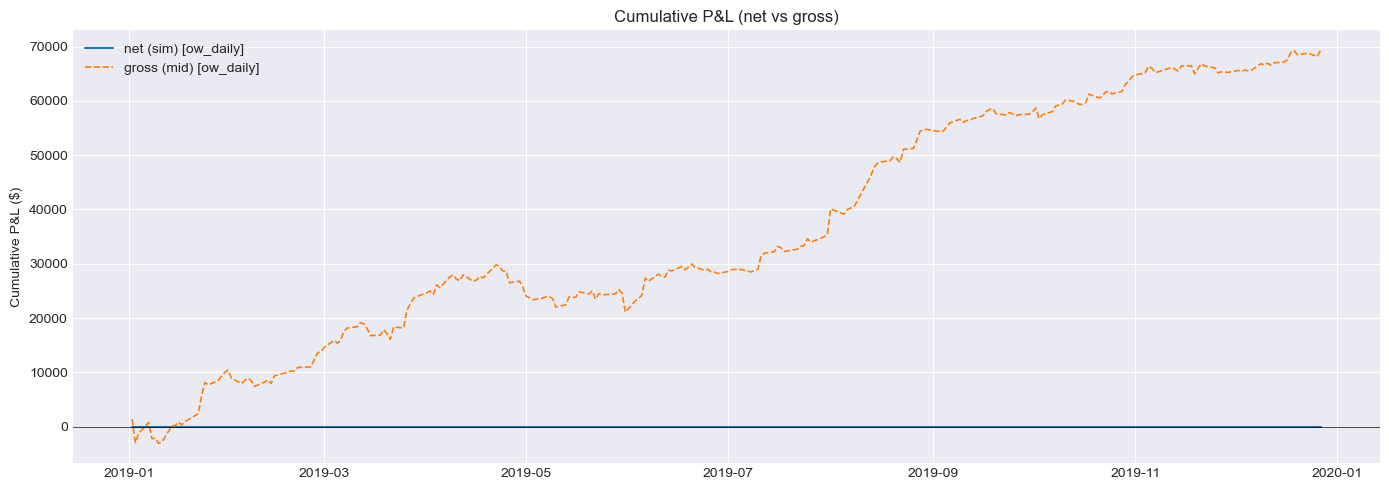

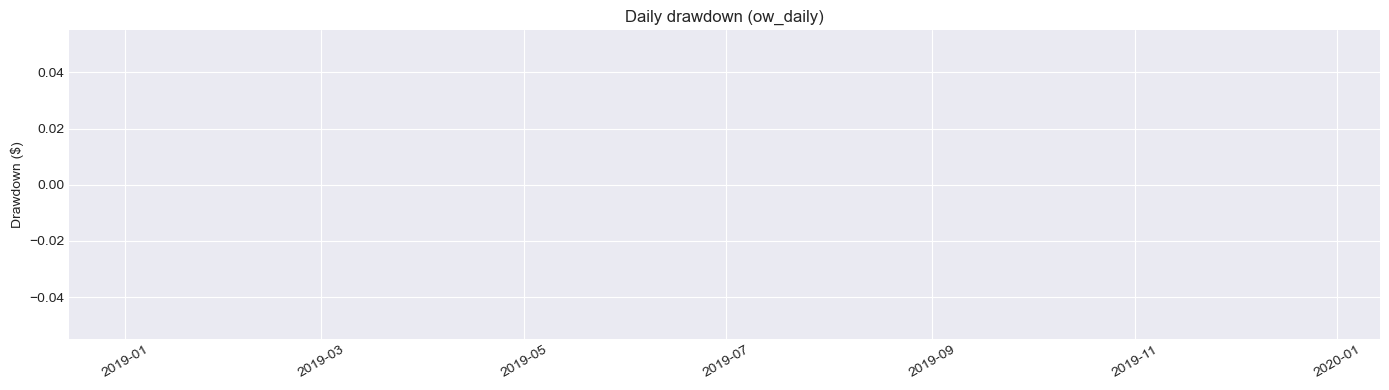

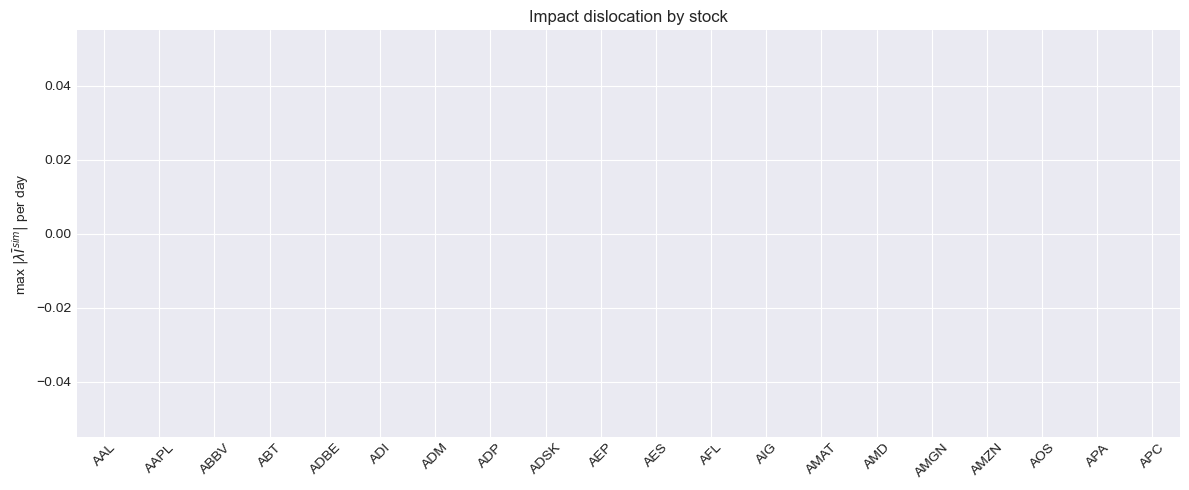

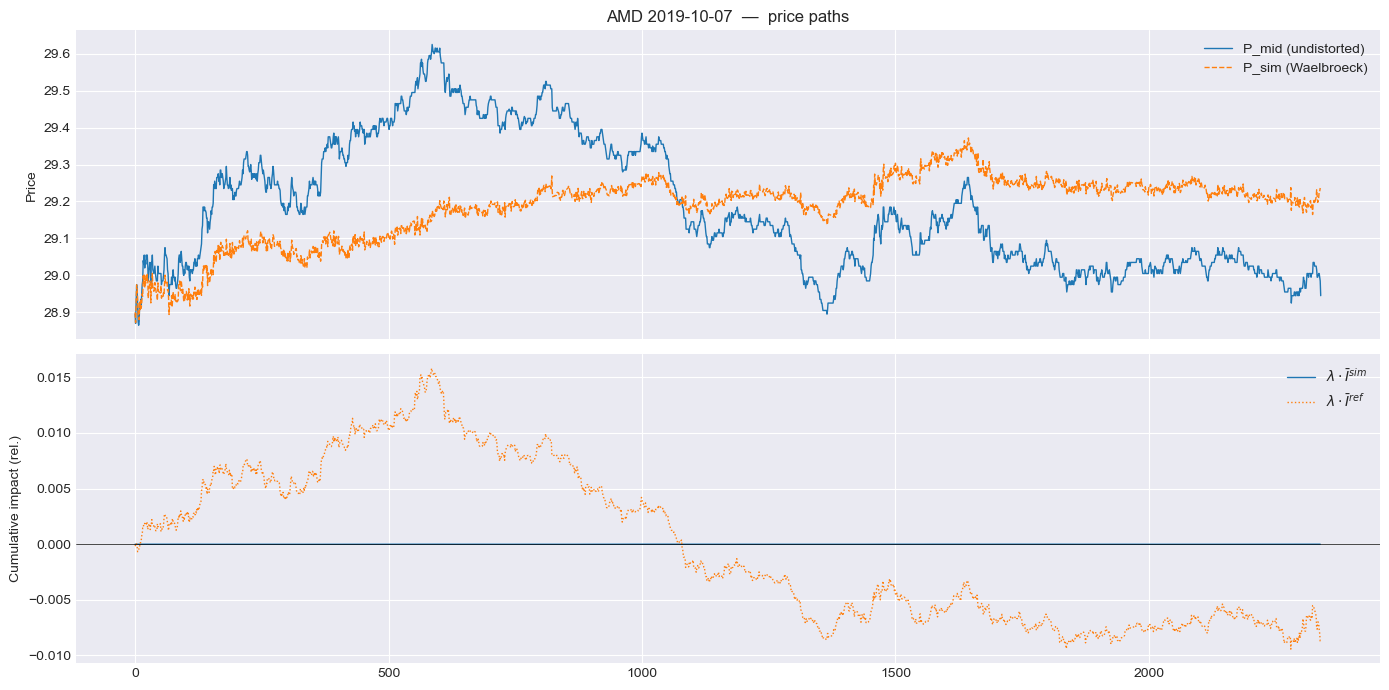

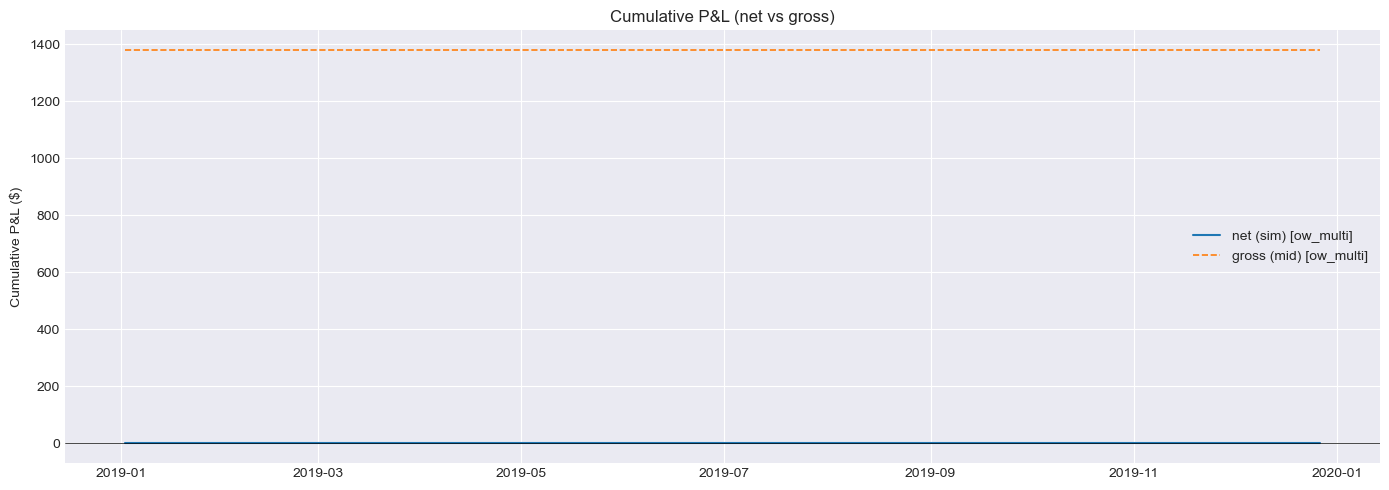

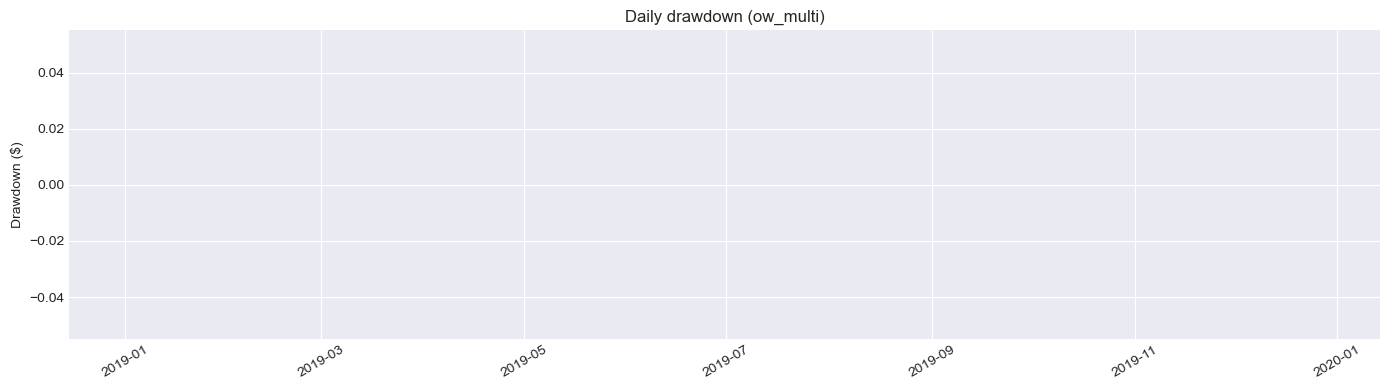

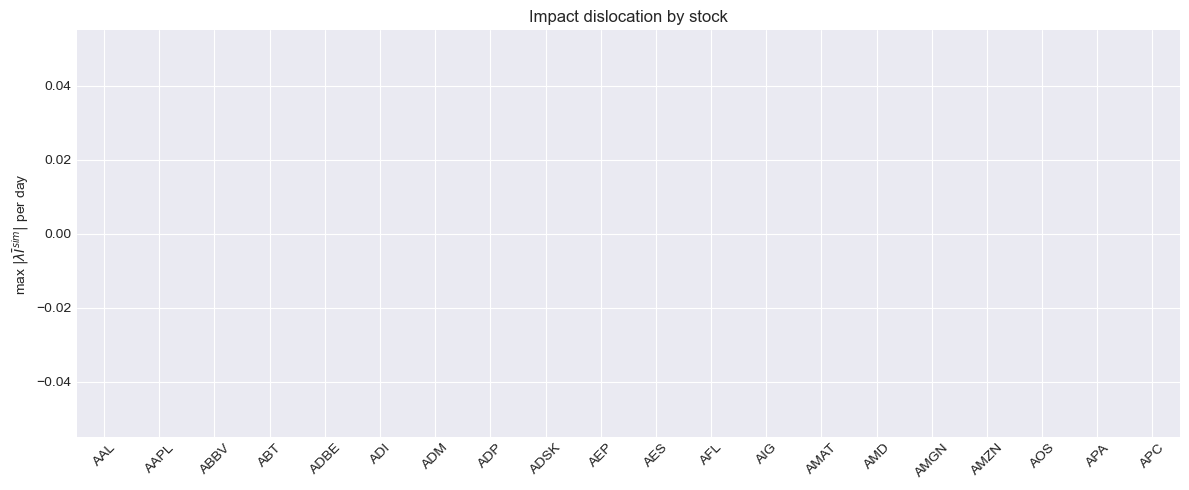

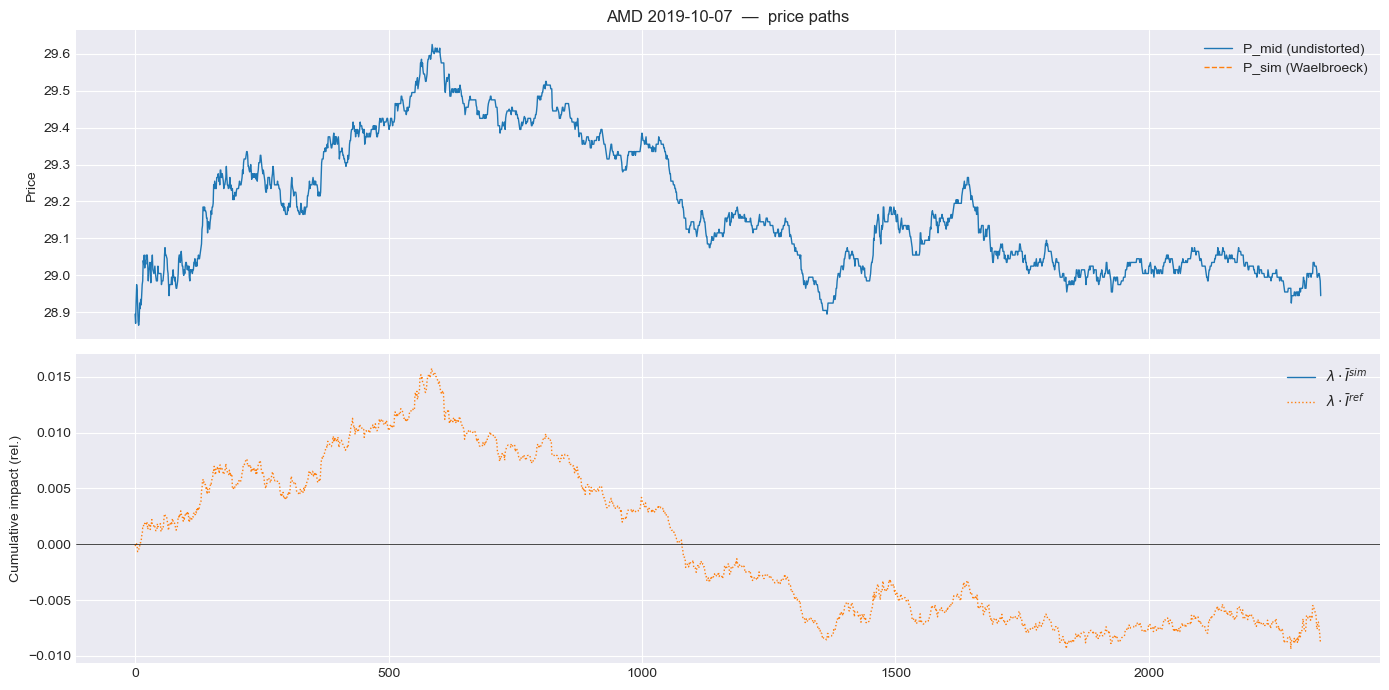

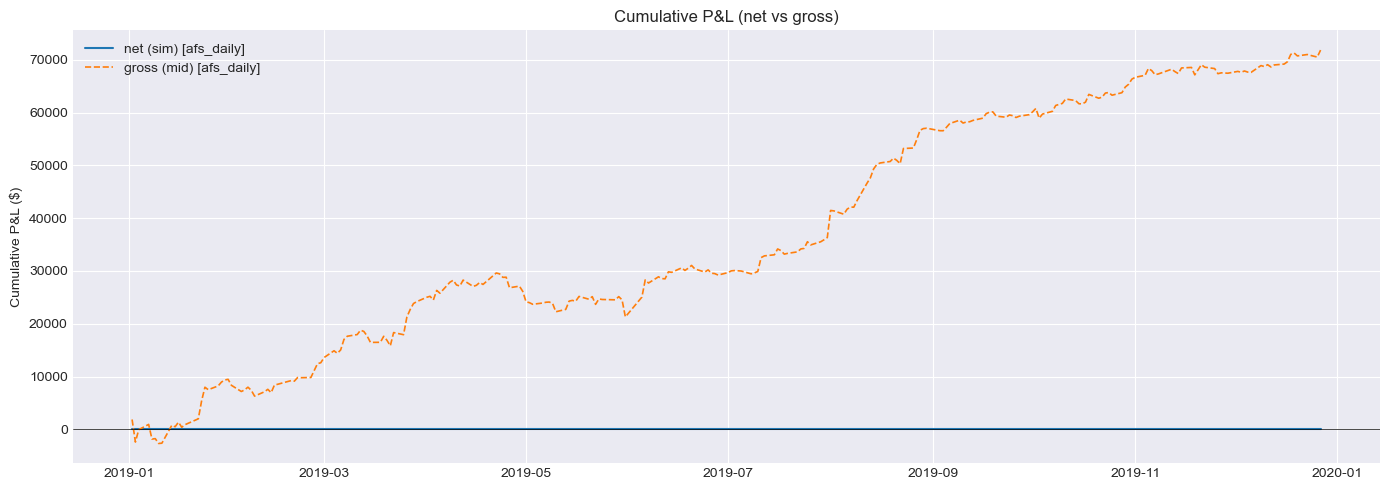

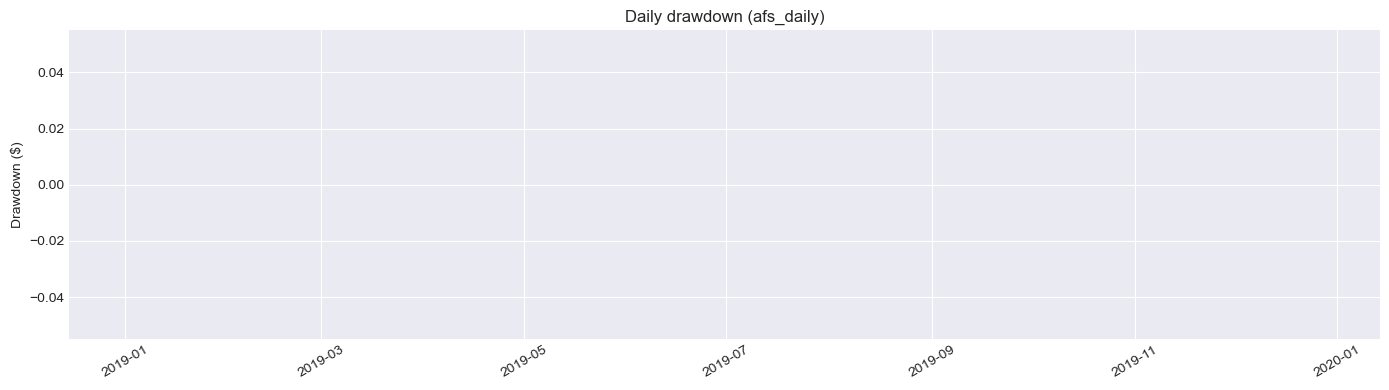

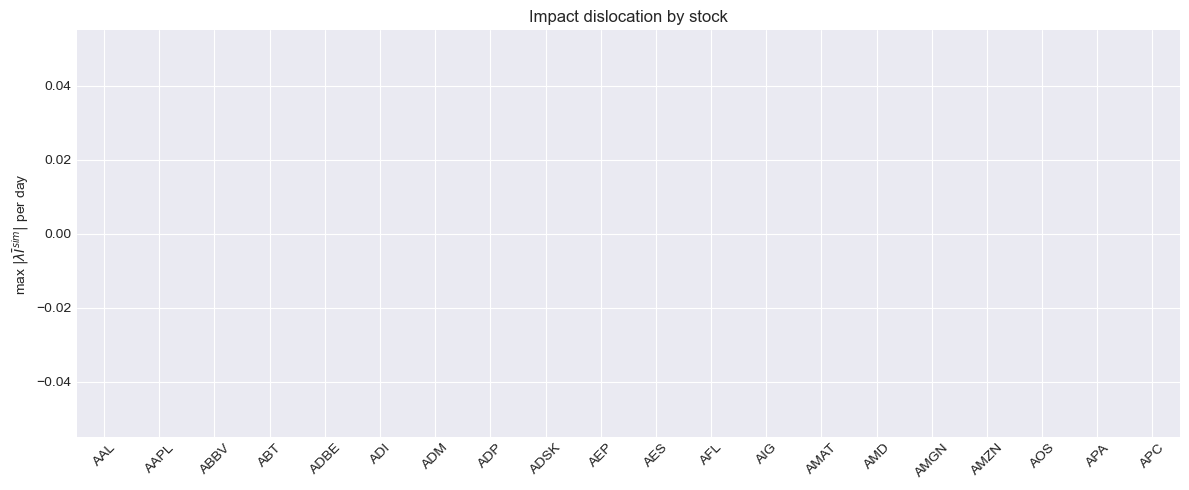

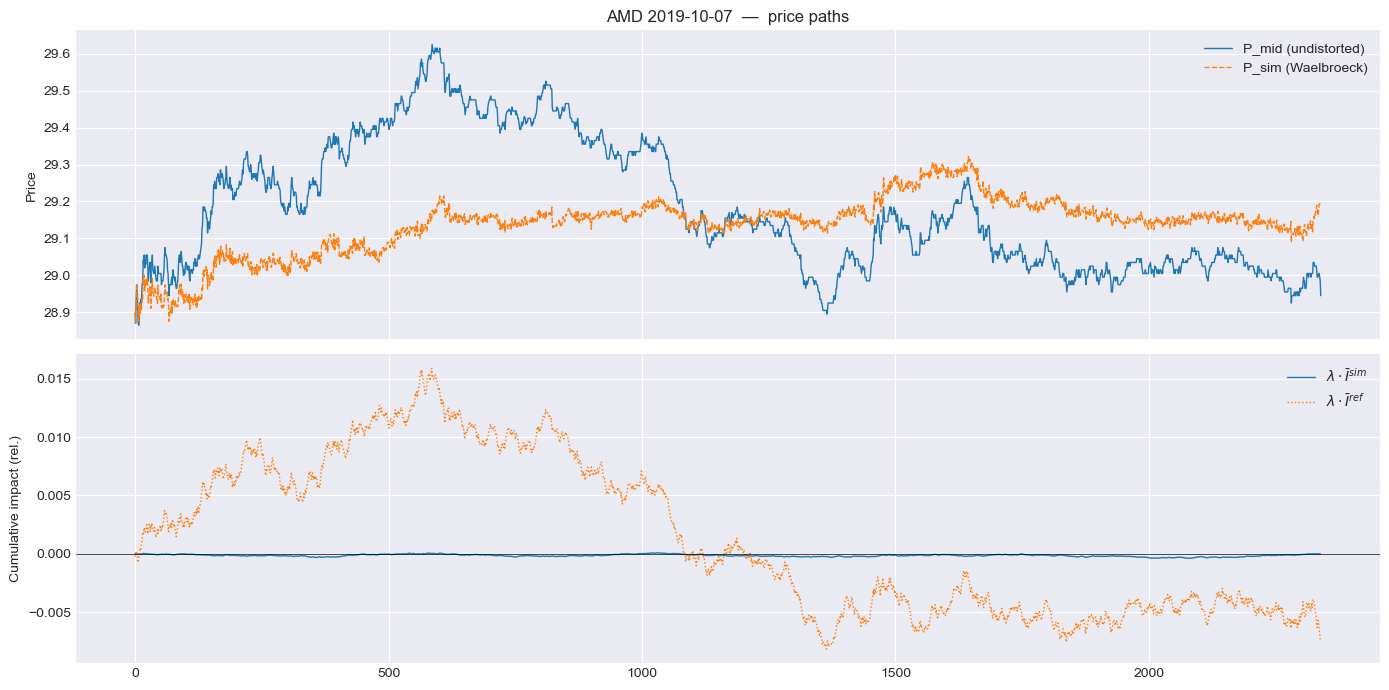

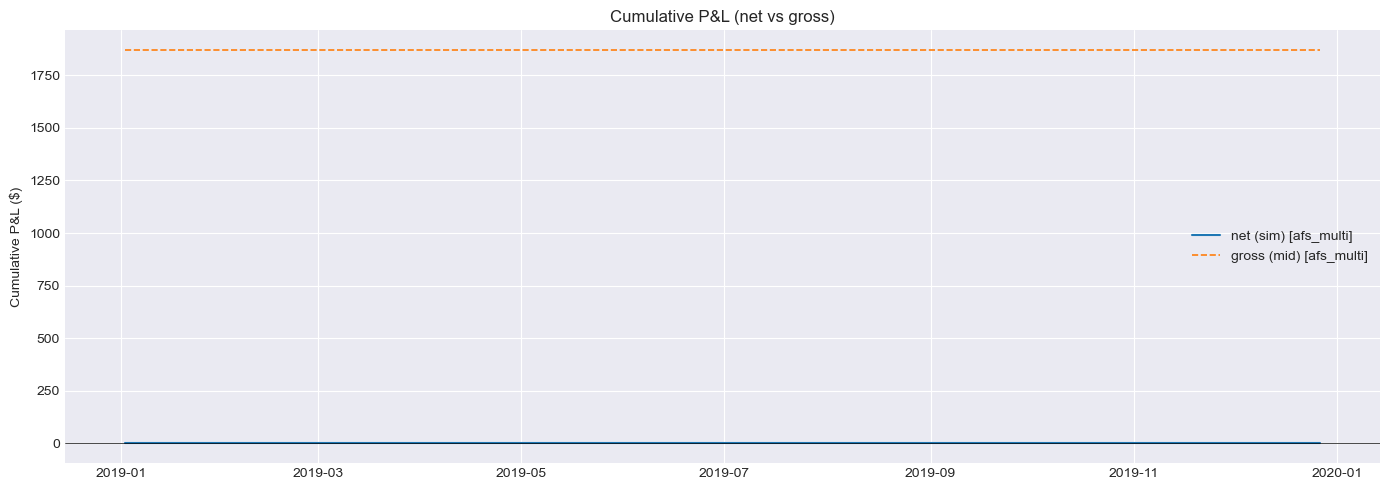

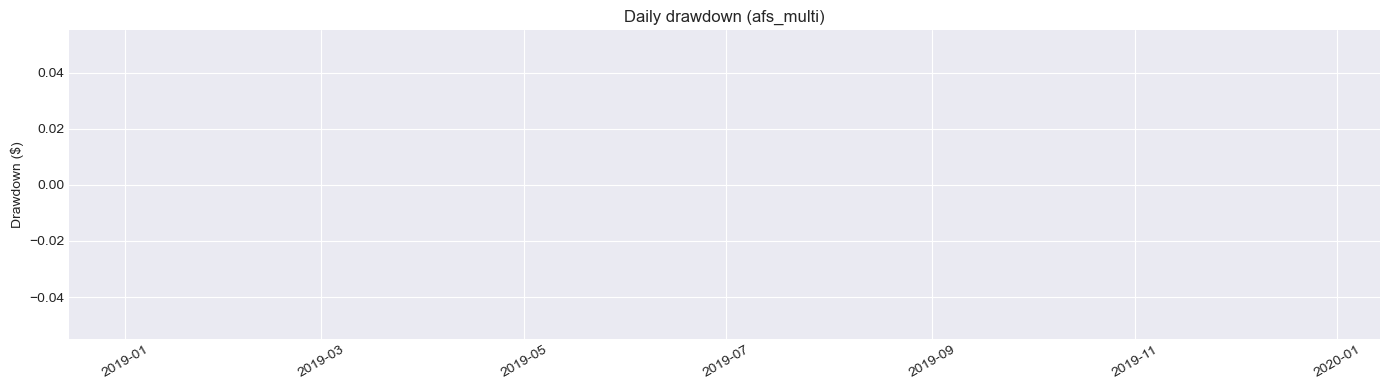

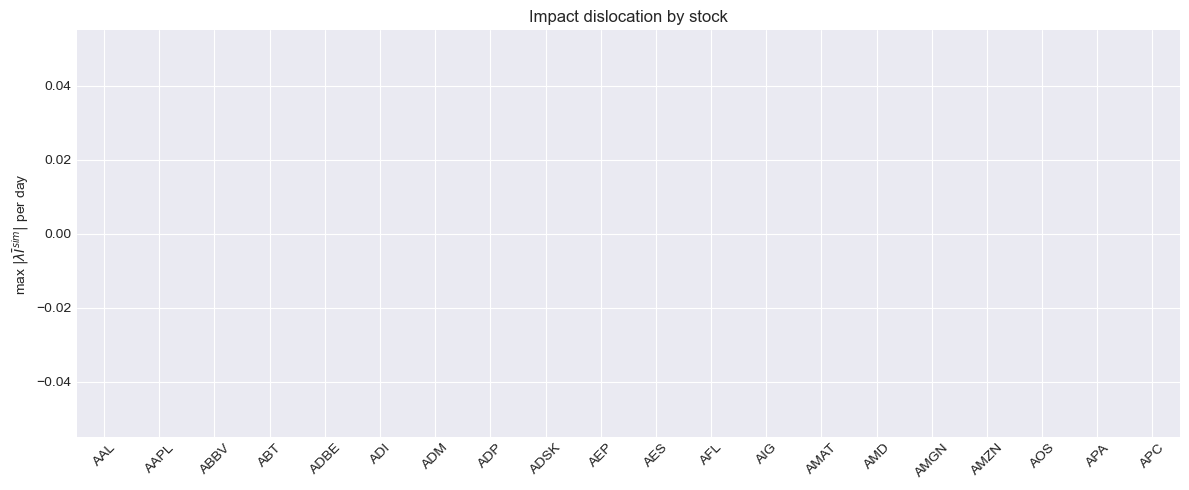

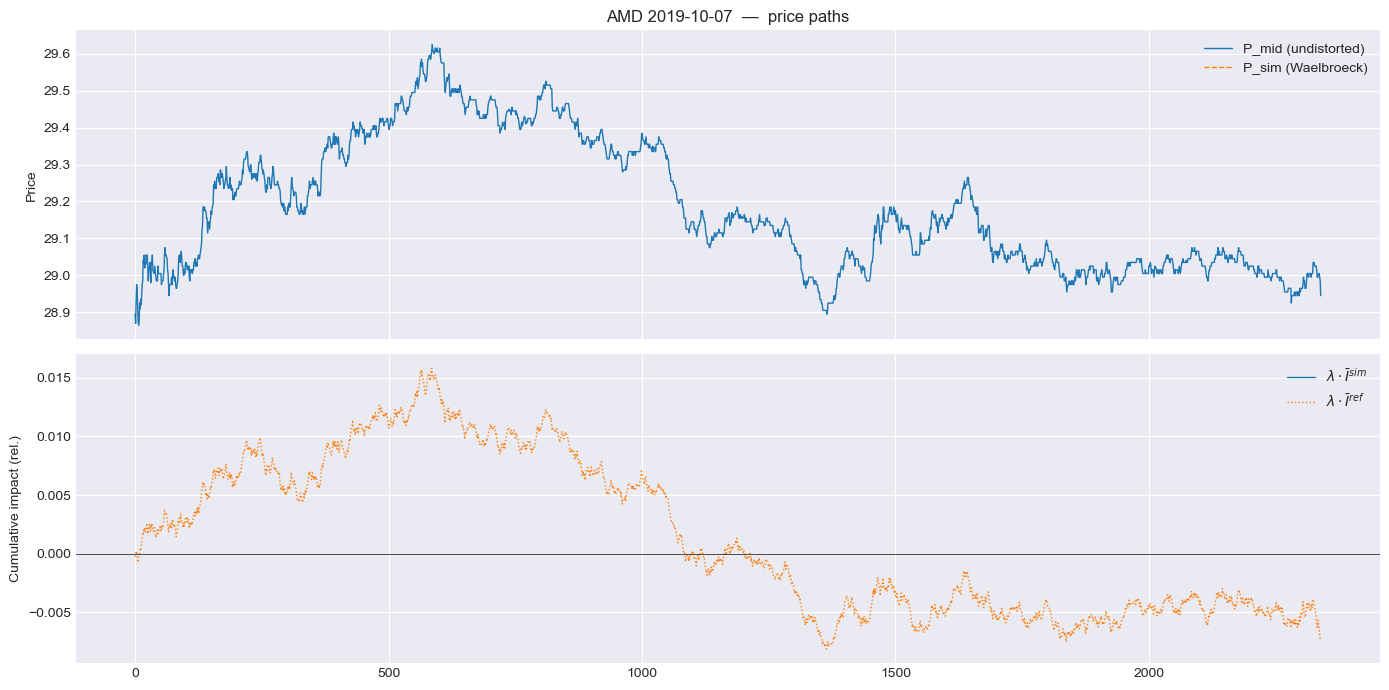

In [14]:
configs = [
    pi.BacktestConfig(
        name="ow_daily",
        model_type="linear",
        strategy="ow",
        carry="daily",
        half_life_minutes=H_star,
        tau_bins=TAU_BINS,
        rho=RHO,
        h_alpha_bins=H_ALPHA_BINS,
    ),
    pi.BacktestConfig(
        name="ow_multi",
        model_type="linear",
        strategy="ow",
        carry="multi",
        half_life_minutes=H_star,
        tau_bins=TAU_BINS,
        rho=RHO,
        h_alpha_bins=H_ALPHA_BINS,
    ),
    pi.BacktestConfig(
        name="afs_daily",
        model_type="sqrt",
        strategy="afs",
        carry="daily",
        half_life_minutes=H_star,
        tau_bins=TAU_BINS,
        rho=RHO,
        h_alpha_bins=H_ALPHA_BINS,
    ),
    pi.BacktestConfig(
        name="afs_multi",
        model_type="sqrt",
        strategy="afs",
        carry="multi",
        half_life_minutes=H_star,
        tau_bins=TAU_BINS,
        rho=RHO,
        h_alpha_bins=H_ALPHA_BINS,
    ),
]

runs = {}
for cfg in configs:
    lam_lookup = (lam_lookup_daily if cfg.carry == "daily" else lam_lookup_multi)[
        cfg.model_type
    ]
    sample_day = (panel.stocks[0], alphas["date"].iloc[len(alphas) // 2])
    out = pi.run_and_save(
        data, daily_stats, alphas, lam_lookup, cfg, sample_path=sample_day
    )
    runs[cfg.name] = out
    print(
        f"{cfg.name:12s}  Sharpe(sim)={out.metrics['sharpe_sim']:+.3f}  "
        f"net P&L=${out.metrics['total_pnl_sim']:>14,.0f}  "
        f"impact cost=${out.metrics['total_impact_cost']:>14,.0f}"
    )


### 7.1 Comparison table


In [15]:
comparison = pd.DataFrame({name: r.metrics for name, r in runs.items()}).T
comparison[
    [
        "n_days",
        "sharpe_sim",
        "sharpe_mid",
        "total_pnl_sim",
        "total_pnl_mid",
        "total_impact_cost",
        "max_drawdown",
        "max_impact_dislocation",
        "win_rate",
    ]
].round(4)


,n_days,sharpe_sim,sharpe_mid,total_pnl_sim,total_pnl_mid,total_impact_cost,max_drawdown,max_impact_dislocation,win_rate
ow_daily,250,NaN,4.25508,0.0,69357.893338,0.0,0.0,NaN,0.0
ow_multi,250,NaN,1.003992,0.0,1379.904586,0.0,0.0,NaN,0.0
afs_daily,250,NaN,4.326556,0.0,71834.772247,0.0,0.0,NaN,0.0
afs_multi,250,NaN,1.003992,0.0,1869.8022,0.0,0.0,NaN,0.0


### 7.2 TCA decomposition


In [16]:
tca_rows = {name: pi.tca_summary(r.tca) for name, r in runs.items()}
tca_summary_df = pd.DataFrame(tca_rows).T
tca_summary_df[
    [
        "gross_pnl",
        "impact_cost",
        "net_pnl",
        "predicted_alpha",
        "realised_alpha",
        "turnover",
        "gross_notional",
    ]
].round(2)


,gross_pnl,impact_cost,net_pnl,predicted_alpha,realised_alpha,turnover,gross_notional
ow_daily,69357.89,NaN,NaN,NaN,69357.89,NaN,NaN
ow_multi,1379.90,NaN,NaN,NaN,1379.90,NaN,NaN
afs_daily,71834.77,NaN,NaN,NaN,71834.77,NaN,NaN
afs_multi,1869.80,NaN,NaN,NaN,1869.80,NaN,NaN


### 7.3 Cumulative P&L — head-to-head


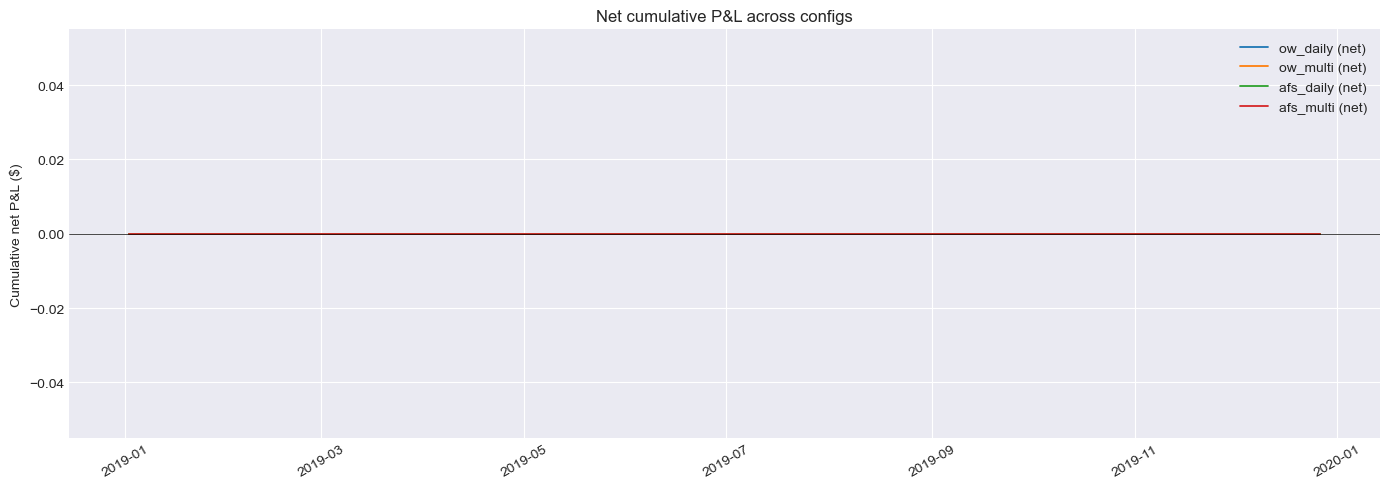

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))
for name, out in runs.items():
    cum = pi.cumulative_pnl(out.daily, "pnl_sim")
    ax.plot(cum.index, cum.values, label=f"{name} (net)", lw=1.3)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cumulative net P&L ($)")
ax.set_title("Net cumulative P&L across configs")
ax.legend()
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


### 7.4 Per-run artifacts

Each run wrote its plots, tables, and config snapshot to `saved/<name>/`. Listing the OW-daily directory as an example:


In [18]:
import os

for name in runs:
    files = sorted(os.listdir(runs[name].paths["dir"]))
    print(f"\n=== saved/{name}/ ===")
    for f in files:
        print(" ", f)



=== saved/ow_daily/ ===
  config.json
  cum_pnl.png
  daily_pnl.csv
  drawdown.png
  impact_dislocation.png
  metrics.csv
  path_AMD_2019-10-07.png
  stock_day_pnl.csv
  tca_stock_day.csv
  tca_summary.csv

=== saved/ow_multi/ ===
  config.json
  cum_pnl.png
  daily_pnl.csv
  drawdown.png
  impact_dislocation.png
  metrics.csv
  path_AMD_2019-10-07.png
  stock_day_pnl.csv
  tca_stock_day.csv
  tca_summary.csv

=== saved/afs_daily/ ===
  config.json
  cum_pnl.png
  daily_pnl.csv
  drawdown.png
  impact_dislocation.png
  metrics.csv
  path_AMD_2019-10-07.png
  stock_day_pnl.csv
  tca_stock_day.csv
  tca_summary.csv

=== saved/afs_multi/ ===
  config.json
  cum_pnl.png
  daily_pnl.csv
  drawdown.png
  impact_dislocation.png
  metrics.csv
  path_AMD_2019-10-07.png
  stock_day_pnl.csv
  tca_stock_day.csv
  tca_summary.csv


## Summary

All pipeline logic lives in `src/price_impact/` and is unit-friendly — the notebook itself is just orchestration. To add a new backtest, build a new `BacktestConfig` and call `run_and_save`; to plug in a custom strategy or a fixed schedule (TWAP / VWAP), pass a `trade_provider` to `run_backtest` and bypass `run_and_save`'s OW/AFS dispatch.

Outstanding work:

- Wire the **extended OW** closed form (time-dependent $\lambda(t)$) into `strategy.ext_ow_optimal_strategy_timedep_lambda`. The simulator already accepts a per-bin $\lambda$ array in `lam_t_lookup`.
- Decide whether to surface VWAP-slippage decomposition (currently the TCA exposes net / gross / impact / predicted-α / realised-α, which are the well-defined ones given our data).
